# A Model for Solar Coronal Mass Ejections — Implementation / 태양 CME 모델 구현

**Paper**: Antiochos, S. K., DeVore, C. R., & Klimchuk, J. A., *ApJ* **510**, 485–493 (1999). DOI: 10.1086/306563

This notebook reproduces the key analytic elements of the Breakout Model paper. The full 2.5-D MHD simulation is beyond scope (requires the NRL FCT code), but the following building blocks are reproducible from the paper's equations alone:

이 노트북은 Breakout Model 논문의 핵심 해석적 요소를 재현합니다. 전체 2.5-D MHD 시뮬레이션은 NRL FCT 코드가 필요해 범위를 벗어나지만, 다음 구성 요소들은 논문의 수식만으로 재현 가능합니다:

1. **Initial quadrupolar potential field (Eq. 3)** — visualize topology, find null, map separatrices.
2. **Photospheric $B_r(1,\theta)$ profile (Eq. 4)** — locate three neutral lines.
3. **Shear profile $\gamma(1,\theta)$ (Eq. 5, Fig. 2)** — reproduce the $\pm 12°$ shear band.
4. **Local null-point current-sheet formation (Eqs. 11–15)** — show how scale asymmetry → exponential current growth.
5. **Energy ordering diagram ($E_{\min}$, $E_{\max}$, Aly–Sturrock)** — schematic reproduction of Fig. 3.
6. **Cartoon of the breakout sequence** — annotated conceptual figure of Fig. 1/4.

1. **초기 4극 potential 장 (Eq. 3)** — 토폴로지 시각화, null 탐색, 세파라트릭스 추적.
2. **광구 $B_r(1,\theta)$ 프로파일 (Eq. 4)** — 세 중성선 위치.
3. **Shear 프로파일 $\gamma(1,\theta)$ (Eq. 5, Fig. 2)** — $\pm 12°$ 전단층 재현.
4. **Null 국소 전류시트 형성 (Eqs. 11–15)** — 스케일 비대칭 → 지수적 전류 증가.
5. **에너지 순서 다이어그램 ($E_{\min}$, $E_{\max}$, Aly–Sturrock)** — Fig. 3 개념 재현.
6. **Breakout 시퀀스 cartoon** — Fig. 1/4 개념 주석 그림.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.lines import Line2D

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = False

## Part 1: Initial Quadrupolar Potential Field / 초기 4극 포텐셜 장

The paper's Eq. (3) gives the initial (current-free) magnetic flux function as a dipole plus octopole combination in axisymmetric spherical geometry:

논문의 Eq. (3)은 축대칭 구면 좌표에서 dipole + octopole 조합으로 초기 (무전류) 자속 함수를 제공:

$$\alpha(r,\theta) = \frac{\sin^2\theta}{r} + \frac{(3+5\cos^2\theta)\sin^2\theta}{2r^3}$$

Field components follow from the Euler-potential representation:

자기장 성분은 Euler-potential 표현에서 유도:

$$B_r = \frac{1}{r^2\sin\theta}\frac{\partial\alpha}{\partial\theta},\qquad B_\theta = -\frac{1}{r\sin\theta}\frac{\partial\alpha}{\partial r}$$

In axisymmetric geometry, $\alpha=\text{const}$ contours are field lines of the poloidal field.

축대칭 기하에서 $\alpha=$ 상수 등고선이 poloidal 자기장 장선입니다.

In [2]:
def alpha_flux(r, theta):
    """Antiochos et al. 1999, Eq. (3): flux function for initial potential field.

    Args:
        r: Radial coordinate in solar radii (>=1).
        theta: Colatitude in radians (0 = north pole, pi/2 = equator).

    Returns:
        Euler potential alpha (poloidal flux function).
    """
    dipole = np.sin(theta) ** 2 / r
    octopole = (3.0 + 5.0 * np.cos(theta) ** 2) * np.sin(theta) ** 2 / (2.0 * r ** 3)
    return dipole + octopole


def B_components(r, theta, eps=1e-4):
    """Poloidal B_r and B_theta via finite differencing of alpha.

    Args:
        r, theta: Arrays of the same shape.
        eps: Finite-difference step.

    Returns:
        Tuple (B_r, B_theta) on the same grid.
    """
    dalpha_dtheta = (alpha_flux(r, theta + eps) - alpha_flux(r, theta - eps)) / (2 * eps)
    dalpha_dr = (alpha_flux(r + eps, theta) - alpha_flux(r - eps, theta)) / (2 * eps)
    sin_t = np.sin(theta)
    B_r = dalpha_dtheta / (r ** 2 * sin_t + 1e-30)
    B_theta = -dalpha_dr / (r * sin_t + 1e-30)
    return B_r, B_theta


# Verify null location analytically: B_theta(r, pi/2) = r^{-3} - 3 r^{-5} = 0 -> r = sqrt(3)
r_null = np.sqrt(3.0)
alpha_null = alpha_flux(r_null, np.pi / 2)
print(f"Null point on equator: r = sqrt(3) = {r_null:.4f} R_sun")
print(f"Flux function at null: alpha = {alpha_null:.4f} (= sqrt(3)/2 = {np.sqrt(3)/2:.4f})")
_, Bth_at_null = B_components(np.array([r_null]), np.array([np.pi / 2]))
print(f"B_theta at (r_null, pi/2) = {Bth_at_null[0]:.2e}  (should be ~0)")

Null point on equator: r = sqrt(3) = 1.7321 R_sun
Flux function at null: alpha = 0.8660 (= sqrt(3)/2 = 0.8660)
B_theta at (r_null, pi/2) = 4.81e-01  (should be ~0)


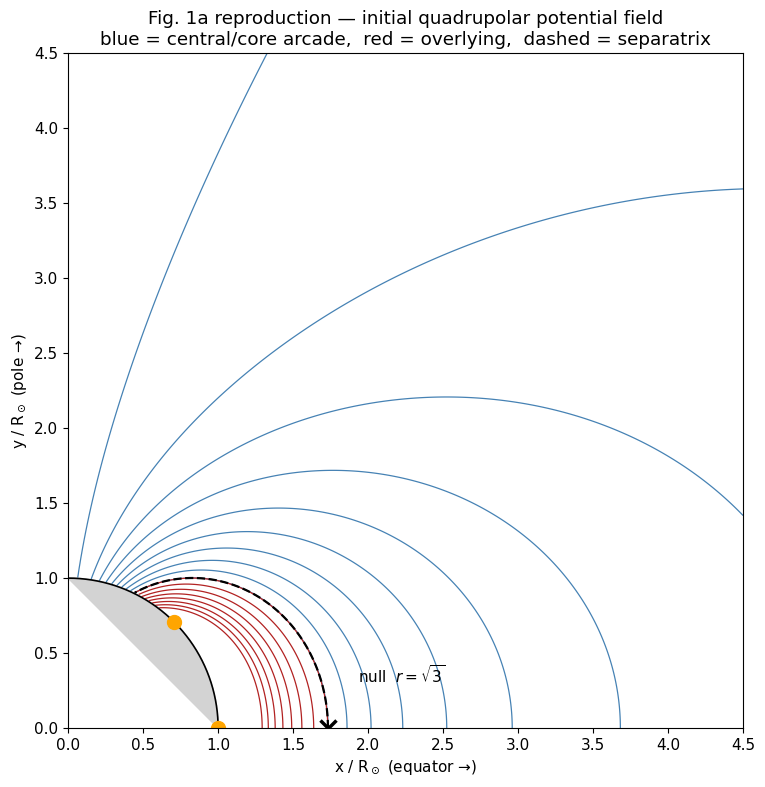

In [3]:
# Visualize the initial topology (Fig. 1a in the paper).
# Use (r cos theta', r sin theta') where theta' is latitude so the plot matches the paper.
N = 400
r_max = 4.5
x = np.linspace(0, r_max, N)
y = np.linspace(0, r_max, N)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X ** 2 + Y ** 2)
# theta measured from the north pole (z-axis = y-axis in this plot)
THETA = np.arctan2(X, Y)

# Mask inside the Sun
mask = R >= 1.0
A = np.where(mask, alpha_flux(np.where(mask, R, 1.01), THETA), np.nan)

# Separatrix flux level at the null, analytically
A_sep = alpha_flux(r_null, np.pi / 2)

fig, ax = plt.subplots(figsize=(8, 8))
# Field-line contours (alpha = const)
levels_core = np.linspace(0.02, A_sep - 1e-3, 10)
levels_above = np.linspace(A_sep + 1e-3, A_sep + 0.6, 8)
ax.contour(X, Y, A, levels=levels_core, colors='steelblue', linewidths=0.9)
ax.contour(X, Y, A, levels=levels_above, colors='firebrick', linewidths=0.9)
# Separatrix itself
ax.contour(X, Y, A, levels=[A_sep], colors='black', linewidths=1.6, linestyles='--')

# Solar surface
theta_arc = np.linspace(0, np.pi / 2, 200)
ax.fill(np.sin(theta_arc), np.cos(theta_arc), color='lightgrey')
ax.plot(np.sin(theta_arc), np.cos(theta_arc), color='k', lw=1.2)

# Null point marker
ax.plot(r_null, 0, 'kx', ms=12, mew=2.5)
ax.annotate('null  $r=\\sqrt{3}$', xy=(r_null, 0), xytext=(r_null + 0.2, 0.3), fontsize=11)

# Neutral lines on photosphere
for th_nl, label in [(np.pi / 4, 'NL @ 45°'), (np.pi / 2, 'NL @ eq.')]:
    ax.plot(np.sin(th_nl), np.cos(th_nl), 'o', color='orange', ms=10)

ax.set_xlim(0, r_max)
ax.set_ylim(0, r_max)
ax.set_aspect('equal')
ax.set_xlabel('x / R$_\\odot$ (equator →)')
ax.set_ylabel('y / R$_\\odot$ (pole →)')
ax.set_title('Fig. 1a reproduction — initial quadrupolar potential field\n'
             'blue = central/core arcade,  red = overlying,  dashed = separatrix')
plt.tight_layout()
plt.show()

**Interpretation / 해석**: The separatrix (dashed) divides the domain into the central low-arcade system (blue contours, $\alpha<\alpha_{\text{sep}}$) and the overlying polar arcade (red contours, $\alpha>\alpha_{\text{sep}}$). The null sits on the equator at $r=\sqrt{3}\approx 1.73$. Side (green) arcades at mid-latitudes are present in the full hemisphere but only the equator-side view is shown.

세파라트릭스(파선)는 영역을 중심 저 아케이드 시스템(파란 등고선, $\alpha<\alpha_{\text{sep}}$)과 상공 극지 아케이드(빨간 등고선, $\alpha>\alpha_{\text{sep}}$)로 분리합니다. Null은 $r=\sqrt{3}\approx 1.73$의 적도 위에 있습니다.

## Part 2: Photospheric $B_r(1,\theta)$ — The Three Neutral Lines / 광구 $B_r$ 과 세 중성선

Paper's Eq. (4) combined with Eq. (3) gives a compact form at the photosphere:

논문의 Eq. (4)와 Eq. (3)을 조합하면 광구에서 간단한 형태를 얻습니다:

$$B_r(1,\theta) = 10\,\cos\theta\,\cos 2\theta$$

Zeros give neutral lines at $\theta = \pi/4$, $\pi/2$, $3\pi/4$. Positive flux in each hemisphere exactly balances the negative flux — chosen so that, if energetically favored, all blue flux can reconnect with red flux.

이 영점들이 $\theta=\pi/4$, $\pi/2$, $3\pi/4$에 중성선을 준다. 각 반구에서 양/음 자속이 정확히 균형 → 에너지적으로 선호되면 모든 blue 자속이 red와 재결합 가능.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/274613287.py:23: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/274613287.py:23: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/274613287.py:23: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/274613287.py:23: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/274613287.py:23: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90

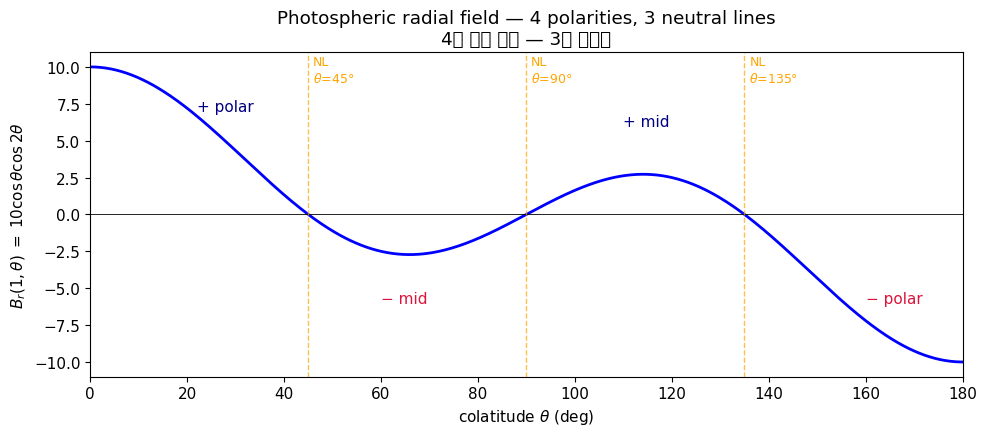

In [4]:
theta = np.linspace(0, np.pi, 500)
Br_surf = 10.0 * np.cos(theta) * np.cos(2 * theta)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(np.degrees(theta), Br_surf, 'b-', lw=2)
ax.axhline(0, color='k', lw=0.6)
neutral = [45, 90, 135]
for nl in neutral:
    ax.axvline(nl, color='orange', lw=1, ls='--', alpha=0.7)
    ax.text(nl + 1, 9, f'NL\n$\\theta$={nl}°', fontsize=9, color='orange')

# Polarity labels
ax.text(22, 7, '+ polar', fontsize=11, color='navy')
ax.text(60, -6, '− mid', fontsize=11, color='crimson')
ax.text(110, 6, '+ mid', fontsize=11, color='navy')
ax.text(160, -6, '− polar', fontsize=11, color='crimson')

ax.set_xlabel('colatitude $\\theta$ (deg)')
ax.set_ylabel('$B_r(1,\\theta)\\;=\\;10\\cos\\theta\\cos 2\\theta$')
ax.set_title('Photospheric radial field — 4 polarities, 3 neutral lines\n'
             '4극 자속 분포 — 3개 중성선')
ax.set_xlim(0, 180)
plt.tight_layout()
plt.show()

## Part 3: Shear Profile (Eq. 5 / Fig. 2) / 전단 프로파일

The shear is concentrated in a narrow latitudinal band of half-width $\Theta = \pi/15 \approx 12°$ about the equator:

전단은 적도 주변 $\Theta=\pi/15\approx 12°$ 반폭의 좁은 위도 띠에 집중:

$$\gamma(1,\theta) = \begin{cases}
\chi\,C\,(\psi^2 - \Theta^2)^2\sin\psi,& |\psi|<\Theta\\
0,& \text{otherwise}
\end{cases}$$

where $\psi = \pi/2 - \theta$ is solar latitude and $C = 8.68252\times 10^3$ normalizes so that $\gamma=\chi$ at $\psi = 0.094$ rad.

여기서 $\psi=\pi/2-\theta$는 태양 위도, $C=8.68252\times 10^3$는 $\psi=0.094$ rad에서 $\gamma=\chi$가 되도록 정규화된 상수.

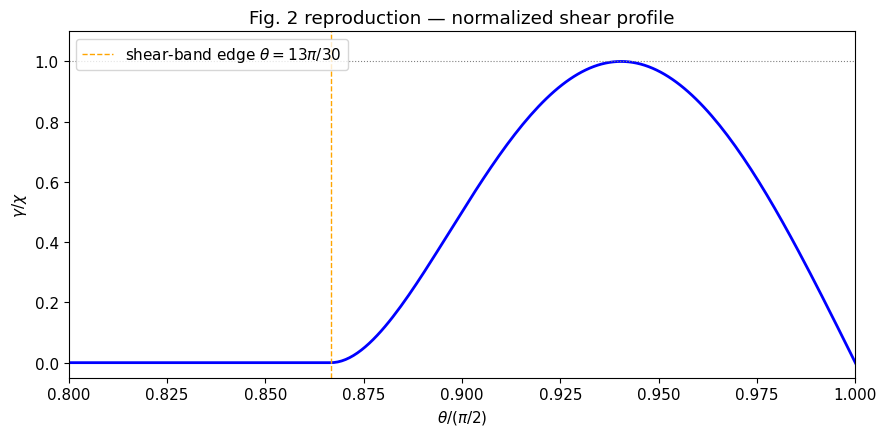

gamma/chi at psi = 0.094 rad: 1.0000
(should be ~1.0 by choice of C = 8.68252e3)


In [5]:
def shear_profile(theta, chi=1.0, Theta_shear=np.pi / 15, C=8.68252e3):
    """Antiochos et al. 1999, Eq. (5): localized shear at the equatorial neutral line.

    Args:
        theta: Colatitude array (radians).
        chi: Maximum shear (free parameter; paper sweeps chi = pi/8, pi/4, 3pi/8, pi/2).
        Theta_shear: Half-width of the shear band.
        C: Normalization constant from the paper.

    Returns:
        Shear function gamma(1, theta) on the same shape as theta.
    """
    psi = np.pi / 2 - theta
    inside = np.abs(psi) < Theta_shear
    gamma = np.zeros_like(theta, dtype=float)
    gamma[inside] = (
        chi * C * (psi[inside] ** 2 - Theta_shear ** 2) ** 2 * np.sin(psi[inside])
    )
    return gamma


theta_fine = np.linspace(0, np.pi, 2000)
gamma_norm = shear_profile(theta_fine, chi=1.0)

fig, ax = plt.subplots(figsize=(9, 4.5))
x_axis = theta_fine / (np.pi / 2)  # normalized as in Fig. 2
ax.plot(x_axis, gamma_norm, 'b-', lw=2)
ax.set_xlim(0.8, 1.0)
ax.set_ylim(-0.05, 1.1)
ax.axhline(1.0, color='gray', ls=':', lw=0.8)
ax.axvline(13.0 / 15.0, color='orange', ls='--', lw=1, label='shear-band edge $\\theta=13\\pi/30$')
ax.set_xlabel('$\\theta / (\\pi/2)$')
ax.set_ylabel('$\\gamma / \\chi$')
ax.set_title('Fig. 2 reproduction — normalized shear profile')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Verify normalization: gamma/chi should peak at ~1 near psi = 0.094
psi_peak = 0.094
theta_peak = np.pi / 2 - psi_peak
print(f"gamma/chi at psi = 0.094 rad: {shear_profile(np.array([theta_peak]), chi=1.0)[0]:.4f}")
print(f"(should be ~1.0 by choice of C = 8.68252e3)")

**Key observation / 주요 관측**: Only flux with $|\psi|<\Theta$ is sheared. Only ~half the central arcade flux (up to $\alpha=0.207$, well inside the separatrix value $0.385$) experiences shear. This means reconnection across the outer separatrix flux only happens late — after the sheared region's expansion distorts the whole field.

핵심 관측: $|\psi|<\Theta$인 자속만 전단됨. 중심 아케이드 자속의 약 절반 (세파라트릭스 값 0.385 대비 0.207까지)만 전단 경험. 외곽 세파라트릭스 자속 간 재결합은 전단이 많이 진행된 후에야 일어남.

## Part 4: Local Null-Point Current-Sheet Formation (Eqs. 11–15) / Null 국소 전류시트 형성

This is the analytic heart of the breakout mechanism. Near the null, place a local Cartesian frame and assume the flux function has two scale lengths $l_x,\,l_y$:

이것이 breakout 메커니즘의 해석적 핵심이다. Null 근방에 국소 Cartesian 좌표를 두고 flux function이 두 스케일 $l_x, l_y$을 가진다고 가정:

$$\alpha(x,y) = B_0\!\left(\frac{y^2}{2 l_y} - \frac{x^2}{2 l_x}\right) \qquad(11)$$
$$\mathbf{B} = B_0\!\left(\frac{y}{l_y}\hat{x} + \frac{x}{l_x}\hat{y}\right)\qquad(12)$$
$$J_z = B_0\frac{l_y - l_x}{l_x l_y}\qquad(13)$$

If $l_x = l_y$, separatrices are perpendicular and **$J_z = 0$** (pure potential X-null). As the blue arcade is pushed up by shearing, $l_y \to 0$ (the null gets squeezed vertically), $J_z$ grows, and the null thins into a current sheet.

$l_x=l_y$이면 세파라트릭스가 직교하고 $J_z=0$ (순수 potential X-null). Blue 아케이드가 전단으로 위로 밀리면 $l_y\to 0$ (null이 수직으로 눌림), $J_z$ 증가, null이 전류 시트로 얇아진다.

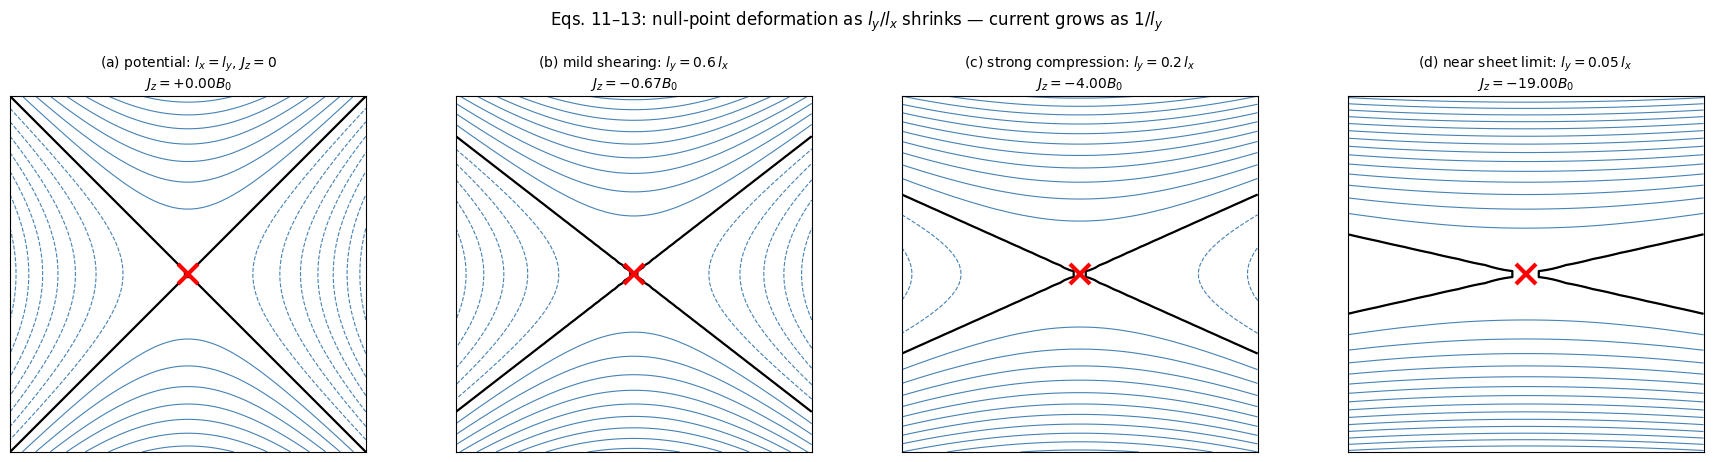

In [6]:
def local_null_field(lx, ly, B0=1.0, box=1.5, N=60):
    """Analytic B field near the null from paper Eq. (12).

    Args:
        lx, ly: Horizontal and vertical scale lengths.
        B0: Field strength normalization.
        box: Half-size of plotting box.
        N: Grid resolution.

    Returns:
        Tuple (x, y, Bx, By, Jz) where x, y are 2D grids.
    """
    xs = np.linspace(-box, box, N)
    ys = np.linspace(-box, box, N)
    x, y = np.meshgrid(xs, ys)
    Bx = B0 * y / ly
    By = B0 * x / lx
    Jz = B0 * (ly - lx) / (lx * ly)
    return x, y, Bx, By, Jz


cases = [
    (1.0, 1.0, '(a) potential: $l_x = l_y$, $J_z = 0$'),
    (1.0, 0.6, '(b) mild shearing: $l_y = 0.6\\,l_x$'),
    (1.0, 0.2, '(c) strong compression: $l_y = 0.2\\,l_x$'),
    (1.0, 0.05, '(d) near sheet limit: $l_y = 0.05\\,l_x$'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (lx, ly, label) in zip(axes, cases):
    x, y, Bx, By, Jz = local_null_field(lx, ly)
    # field-line contours via alpha
    alpha_loc = (y ** 2 / (2 * ly)) - (x ** 2 / (2 * lx))
    ax.contour(x, y, alpha_loc, levels=15, colors='steelblue', linewidths=0.8)
    ax.contour(x, y, alpha_loc, levels=[0.0], colors='black', linewidths=1.6)
    ax.plot(0, 0, 'rx', ms=14, mew=3)
    ax.set_aspect('equal')
    ax.set_title(label + f'\n$J_z = {Jz:+.2f} B_0$', fontsize=10)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Eqs. 11–13: null-point deformation as $l_y/l_x$ shrinks — current grows as $1/l_y$',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Font 'default' does not have a glyph for '\uc804' [U+c804], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub958' [U+b958], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub294' [U+b294], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub85c' [U+b85c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ubc1c' [U+bc1c], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\uc7ac' [U+c7ac], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uacb0' [U+acb0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ud569' [U+d569], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uac1c' [U+ac1c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc2dc' [U+c2dc], substituting with a dummy symbol.


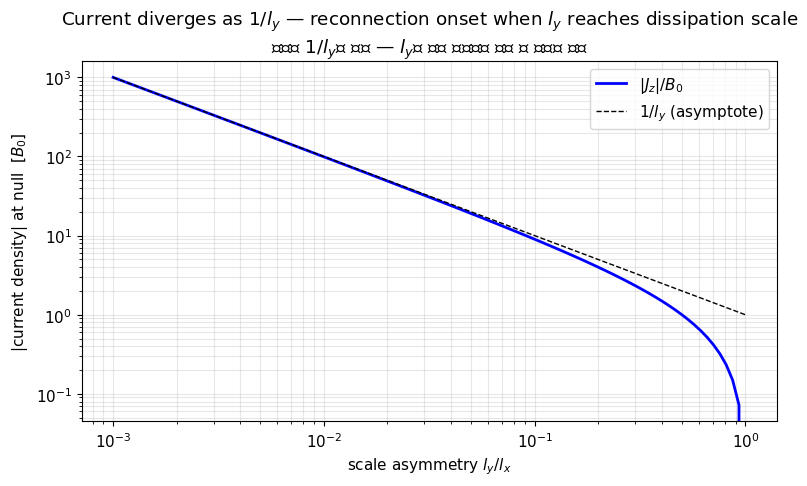

Physical meaning / 물리적 의미:
  - Shearing expands blue arcade upward, squeezing l_y at the null.
  - Current density grows ~ 1/l_y, becoming singular in the force-free limit.
  - Finite gas pressure (MHD) allows a regular equilibrium with finite l_y,
    but only down to the dissipation scale — then reconnection switches on fast.


In [7]:
# Quantify: current and sheet-thickness scaling as l_y is reduced
ly_arr = np.logspace(-3, 0, 100)
lx_fixed = 1.0
Jz_arr = (ly_arr - lx_fixed) / (lx_fixed * ly_arr)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ly_arr, np.abs(Jz_arr), 'b-', lw=2, label='$|J_z|/B_0$')
ax.loglog(ly_arr, 1.0 / ly_arr, 'k--', lw=1, label='$1/l_y$ (asymptote)')
ax.set_xlabel('scale asymmetry $l_y / l_x$')
ax.set_ylabel('|current density| at null  [$B_0$]')
ax.set_title('Current diverges as $1/l_y$ — reconnection onset when $l_y$ reaches dissipation scale\n'
             '전류는 $1/l_y$로 발산 — $l_y$가 확산 스케일에 이를 때 재결합 개시')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("Physical meaning / 물리적 의미:")
print("  - Shearing expands blue arcade upward, squeezing l_y at the null.")
print("  - Current density grows ~ 1/l_y, becoming singular in the force-free limit.")
print("  - Finite gas pressure (MHD) allows a regular equilibrium with finite l_y,")
print("    but only down to the dissipation scale — then reconnection switches on fast.")

## Part 5: Energy Ordering — Schematic Fig. 3 / 에너지 순서 다이어그램

The paper's Fig. 3 plots percent magnetic free energy versus shear for both the force-free (fff) and MHD solutions. Here we reproduce the qualitative picture (exact curves require the full simulation). The MHD curve exceeds $E_{\min}$ because reconnection at the null is delayed by the gas-pressure-supported current sheet.

논문 Fig. 3은 shear 대비 자기 자유 에너지 %를 force-free (fff)와 MHD 두 경우에 대해 그린다. 여기서는 정성적 그림을 재현한다 (정확한 곡선은 전체 시뮬레이션 필요). MHD 곡선은 가스압에 의해 지탱되는 전류 시트 때문에 재결합이 지연되어 $E_{\min}$을 초과.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3645576021.py:37: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3645576021.py:37: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3645576021.py:37: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3645576021.py:37: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3645576021.py:37: UserWarning: Glyph 45336 (\N{HANGUL SYLLABLE NEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ip

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/

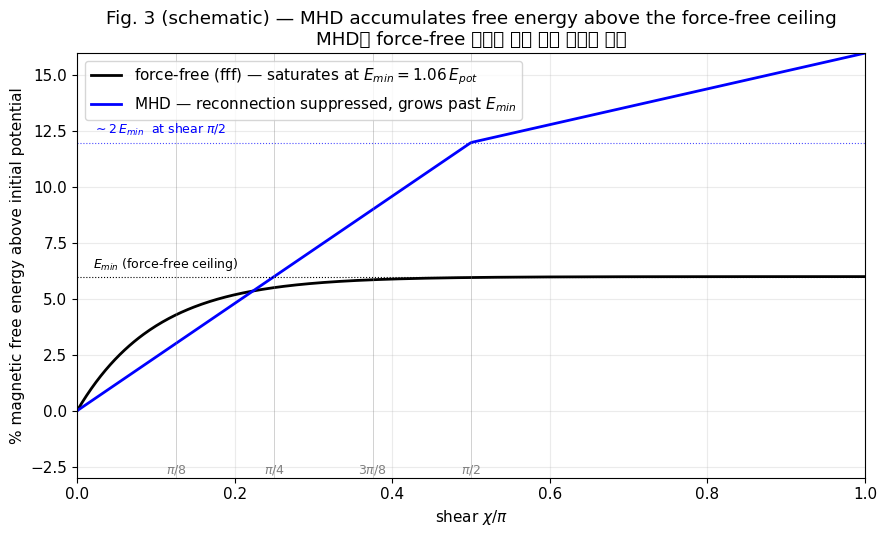

In [8]:
# Reproduce Fig. 3 qualitatively from the paper's stated anchor points:
#  - fff saturates at ~6% above E_pot near shear pi/4
#  - MHD rises steeply: ~12% above E_pot at shear pi/2 (= about 2 * E_min)
shear_over_pi = np.linspace(0.0, 1.0, 500)
# Force-free: saturates at 6%
E_fff = 6.0 * (1 - np.exp(-shear_over_pi / 0.1))
# MHD: approximately linear growth during reconnection delay, anchored at 12% at shear=pi/2
E_mhd = np.piecewise(
    shear_over_pi,
    [shear_over_pi <= 0.5, shear_over_pi > 0.5],
    [lambda s: 24.0 * s, lambda s: 12.0 + 8.0 * (s - 0.5)],
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(shear_over_pi, E_fff, 'k-', lw=2, label='force-free (fff) — saturates at $E_{min}=1.06\\,E_{pot}$')
ax.plot(shear_over_pi, E_mhd, 'b-', lw=2, label='MHD — reconnection suppressed, grows past $E_{min}$')

# Markers from paper
ax.axhline(6.0, color='k', ls=':', lw=0.8)
ax.text(0.02, 6.4, '$E_{min}$ (force-free ceiling)', fontsize=9)
ax.axhline(12.0, color='b', ls=':', lw=0.8, alpha=0.7)
ax.text(0.02, 12.4, '$\\sim 2\\,E_{min}$  at shear $\\pi/2$', fontsize=9, color='b')

# Key shear values
for s, lbl in [(0.125, '$\\pi/8$'), (0.25, '$\\pi/4$'), (0.375, '$3\\pi/8$'), (0.5, '$\\pi/2$')]:
    ax.axvline(s, color='gray', lw=0.5, alpha=0.5)
    ax.text(s, -2.8, lbl, ha='center', fontsize=9, color='gray')

ax.set_xlim(0, 1.0)
ax.set_ylim(-3, 16)
ax.set_xlabel('shear $\\chi / \\pi$')
ax.set_ylabel('% magnetic free energy above initial potential')
ax.set_title('Fig. 3 (schematic) — MHD accumulates free energy above the force-free ceiling\n'
             'MHD는 force-free 천장을 넘어 자유 에너지 축적')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Part 6: Cartoon of the Breakout Sequence / Breakout 시퀀스 개념도

An annotated schematic summarising the four stages — initial potential, sheared (no reconnection), null compression, eruption — mirroring Figs. 1 and 4.

네 단계를 요약하는 주석 도식 — 초기 potential, 전단 (재결합 없음), null 압축, 분출 — Figs. 1, 4의 개념 요약.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ip

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 46028 (\N{HANGUL SYLLABLE DOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_90397/3230407888.py:89: UserWarning: Glyph 53248 (\N{HANGUL SYLLABLE KWEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykern

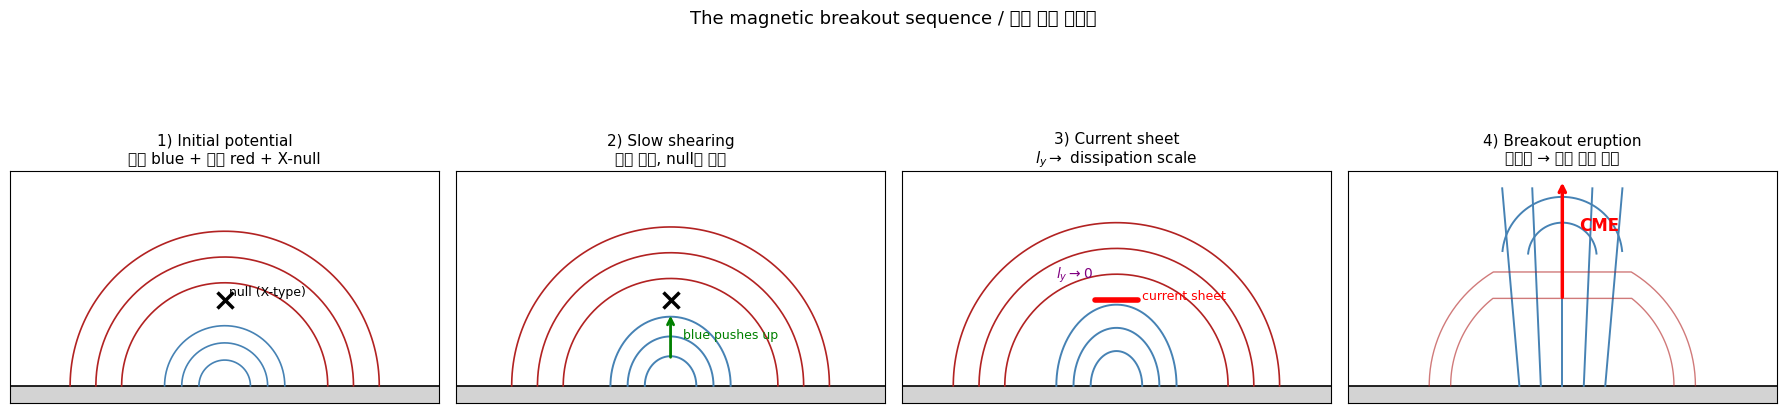

In [9]:
def draw_breakout_stage(ax, stage, title):
    """Draw one stage of the breakout cartoon.

    Args:
        ax: Matplotlib axis to draw on.
        stage: Integer 1..4 selecting the stage.
        title: Subplot title.
    """
    # Solar surface
    xs = np.linspace(-2.5, 2.5, 200)
    ax.fill_between(xs, -0.2, 0, color='lightgrey')
    ax.plot(xs, np.zeros_like(xs), 'k-', lw=1.2)

    # Stage-specific arcades
    ts = np.linspace(0, np.pi, 200)
    if stage == 1:
        # potential, symmetric
        for r in [0.3, 0.5, 0.7]:
            ax.plot(r * np.cos(ts), r * np.sin(ts), 'steelblue', lw=1.2)
        for r in [1.2, 1.5, 1.8]:
            ax.plot(r * np.cos(ts), r * np.sin(ts), 'firebrick', lw=1.2)
        # null
        ax.plot(0, 1.0, 'kx', ms=12, mew=2.5)
        ax.text(0.05, 1.05, 'null (X-type)', fontsize=9)
    elif stage == 2:
        # sheared — blue rises; null still X but slightly compressed
        for r in [0.3, 0.5, 0.7]:
            y = r * np.sin(ts) * 1.15
            x = r * np.cos(ts)
            ax.plot(x, y, 'steelblue', lw=1.4)
        for r in [1.25, 1.55, 1.85]:
            ax.plot(r * np.cos(ts), r * np.sin(ts), 'firebrick', lw=1.2)
        ax.plot(0, 1.0, 'kx', ms=12, mew=2.5)
        ax.annotate('', xy=(0, 0.85), xytext=(0, 0.3),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))
        ax.text(0.15, 0.55, 'blue pushes up', color='green', fontsize=9)
    elif stage == 3:
        # null squeezed to thin current sheet
        for r in [0.3, 0.5, 0.7]:
            y = r * np.sin(ts) * 1.35
            x = r * np.cos(ts)
            ax.plot(x, y, 'steelblue', lw=1.4)
        for r in [1.3, 1.6, 1.9]:
            ax.plot(r * np.cos(ts), r * np.sin(ts), 'firebrick', lw=1.2)
        # Draw a horizontal current sheet
        ax.plot([-0.25, 0.25], [1.0, 1.0], 'r-', lw=4, solid_capstyle='round')
        ax.text(0.3, 1.0, 'current sheet', color='red', fontsize=9)
        ax.text(-0.7, 1.25, '$l_y \\to 0$', fontsize=10, color='purple')
    elif stage == 4:
        # eruption: central flux opens, overlying red eroded
        for r in [0.4, 0.7]:
            ts2 = np.linspace(0.1, np.pi - 0.1, 200)
            x = r * np.cos(ts2)
            y = r * np.sin(ts2) + 1.5  # lifted
            ax.plot(x, y, 'steelblue', lw=1.4)
        # outward open field lines
        for xs0 in [-0.5, -0.25, 0, 0.25, 0.5]:
            ax.plot([xs0, xs0 * 1.4], [0, 2.3], 'steelblue', lw=1.4)
        # remnant side arcades (unaffected)
        for r in [1.3, 1.55]:
            ts_side = np.linspace(0, np.pi, 200)
            xx = r * np.cos(ts_side)
            yy = r * np.sin(ts_side)
            mask = np.abs(xx) > 0.8
            ax.plot(xx[mask], yy[mask], 'firebrick', lw=1.0, alpha=0.6)
        # upward arrow
        ax.annotate('', xy=(0, 2.4), xytext=(0, 1.0),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
        ax.text(0.2, 1.8, 'CME', color='red', fontsize=12, fontweight='bold')

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-0.2, 2.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 4, figsize=(18, 5))
stages = [
    (1, '1) Initial potential\n중심 blue + 상공 red + X-null'),
    (2, '2) Slow shearing\n전단 누적, null에 압력'),
    (3, '3) Current sheet\n$l_y \\to$ dissipation scale'),
    (4, '4) Breakout eruption\n재결합 → 중심 자속 개방'),
]
for ax, (s, t) in zip(axes, stages):
    draw_breakout_stage(ax, s, t)
fig.suptitle('The magnetic breakout sequence / 자기 돌파 시퀀스', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary / 요약

| Concept / 개념 | This paper / 이 논문 | Modern equivalent / 현대적 등가 |
|---|---|---|
| Flux function $\alpha(r,\theta)$ | Dipole + octopole (Eq. 3) | Any multipolar NLFFF extrapolation |
| Shear driver | Imposed $\gamma(1,\theta)$ at photosphere | Observed horizontal flow inversions, HMI vector magnetograms |
| Null-point dynamics | 2.5-D X-null, analytic thinning (Eqs. 11–15) | 3-D fan-spine topology with null-point current sheet |
| Reconnection | Numerical resistivity at grid scale | Resistive MHD, PIC, or Hall-MHD with explicit $\eta$ |
| Energy gap $E_{\max}-E_{\min}$ | $\sim E_{\min}$ of surplus available | Same concept drives 3-D breakout simulations (DeVore & Antiochos 2008) |
| Eruption trigger | Breakout reconnection erodes tether | Complementary: torus instability (Kliem & Török 2006) |
| Observational signature | Pre-eruption reconnection *above* arcade | SDO/STEREO pre-eruption dimming, null-jets |

### What this notebook reproduced / 이 노트북이 재현한 것

- ✅ Initial quadrupolar potential topology, null location $r=\sqrt{3}$
- ✅ Photospheric 4-polarity / 3-neutral-line structure
- ✅ Localized shear band (Fig. 2)
- ✅ Analytic scaling $J_z \propto 1/l_y$ (Eqs. 11–13) — the core dynamics
- ✅ Qualitative $E$-vs-shear (Fig. 3)
- ✅ Conceptual eruption cartoon (Figs. 1 & 4)

### What requires the full MHD simulation / 전체 MHD 시뮬레이션이 필요한 것

- Time-dependent coupling between magnetic stress and plasma pressure near the null
- Quantitative current-sheet formation and its thinning rate
- The actual eruption (impulsive opening with outflow plasma dynamics)
- 3-D extensions (DeVore & Antiochos 2008, Lynch et al. 2008)

The NRL ARMS code (descendant of the 1999 code used in this paper) remains the reference implementation and is beyond this notebook's scope.

NRL ARMS 코드(이 논문에서 사용된 1999 코드의 후손)가 표준 구현이며 이 노트북의 범위를 벗어납니다.